# 09 — Prior-Matched Thresholding on PCA + LSTM-AE Ensemble

Every model in this repo collapses 5–50x between val-tune and val-holdout
F0.5 (NB 08 §7). The detector is not the bottleneck — **thresholding on
38 val events is**. This notebook removes val from the thresholding loop.

**Strategy**
1. Rank-fuse NB 04 PCA + NB 05 LSTM-AE row-level scores (same pair as the
   NB 05 §10 ensemble, which holds our best Kaggle private at 0.476).
2. Pick the threshold so the **test positive rate equals the train prior
   (10.48%)**. This is the best unbiased estimate of test anomaly density
   under distribution shift — no labelled-val F0.5 tuning.
3. Also submit a conservative 5% variant.

**Inputs**: `scores_val_pca.npy`, `scores_test_pca.npy`,
`scores_val_lstm_ae.npy`, `scores_test_lstm_ae.npy`, `y_train_row.npy`
**Outputs**: `submissions/prior_matched_ensemble.parquet`,
`submissions/prior_matched_ensemble_5pct.parquet`

**Sections**
0. Setup & Imports
1. Load Row-Level Scores + Rank-Fuse
2. Train Anomaly Prior
3. Prior-Matched Threshold — Train-prior (10.48%)
4. Sensitivity: Pos-Rate Sweep 1%–20%
5. Conservative Variant — 5% Pos-Rate
6. Generate Submissions
7. Compare with All Prior Submissions

## 0 — Setup & Imports

In [1]:
import sys, json, gc, os
sys.path.insert(0, '../src')

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy.stats import rankdata

from sentinel.ml_logic.data    import find_anomaly_segments
from sentinel.ml_logic.metrics import corrected_event_f05
from sentinel.params import RANDOM_STATE, WINDOW_SIZE, ANOMALY_COLOR, NOMINAL_COLOR

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 110, 'font.size': 10})

PROCESSED_DIR   = Path('../data/processed')
SUBMISSIONS_DIR = Path('../submissions')
RAW_DIR         = Path('../data/raw')

np.random.seed(RANDOM_STATE)
print('Numpy', np.__version__, '  Pandas', pd.__version__)

Numpy 1.26.4   Pandas 2.3.3


---
## 1 — Load Row-Level Scores + Rank-Fuse

PCA and LSTM-AE scores are both stored at **row-level** (2,945,665 val rows,
521,280 test rows). Rank-fuse 50/50 — same weights as the NB 05 §10 ensemble.

In [2]:
with open(PROCESSED_DIR / 'preprocessing_config.json') as f:
    cfg = json.load(f)

SPLIT_IDX = cfg['split_idx']

# Labels
y_train_full = np.load(PROCESSED_DIR / 'y_train_row.npy')
y_val        = y_train_full[SPLIT_IDX:]

# Scores
pca_val    = np.load(PROCESSED_DIR / 'scores_val_pca.npy').astype(np.float32)
lstm_val   = np.load(PROCESSED_DIR / 'scores_val_lstm_ae.npy').astype(np.float32)
pca_test   = np.load(PROCESSED_DIR / 'scores_test_pca.npy').astype(np.float32)
lstm_test  = np.load(PROCESSED_DIR / 'scores_test_lstm_ae.npy').astype(np.float32)

print(f'Val  — PCA {pca_val.shape}  LSTM-AE {lstm_val.shape}  y_val {y_val.shape}')
print(f'Test — PCA {pca_test.shape}  LSTM-AE {lstm_test.shape}')
assert pca_val.shape == lstm_val.shape == y_val.shape
assert pca_test.shape == lstm_test.shape

# 50/50 rank fusion, row-level
def rank01(x): return rankdata(x) / len(x)

val_score  = (0.5 * rank01(pca_val)  + 0.5 * rank01(lstm_val)).astype(np.float32)
test_score = (0.5 * rank01(pca_test) + 0.5 * rank01(lstm_test)).astype(np.float32)

print(f'Ensemble val  range [{val_score.min():.4f}, {val_score.max():.4f}]')
print(f'Ensemble test range [{test_score.min():.4f}, {test_score.max():.4f}]')

Val  — PCA (2945665,)  LSTM-AE (2945665,)  y_val (2945665,)
Test — PCA (521280,)  LSTM-AE (521280,)
Ensemble val  range [0.0012, 1.0000]
Ensemble test range [0.0026, 0.9999]


---
## 2 — Train Anomaly Prior

The full-train positive class rate is our unbiased estimate of test-set
anomaly density. Under drift we don't know whether test is higher or lower,
but the prior is the best single guess.

In [3]:
train_prior = float(y_train_full.mean())
val_prior   = float(y_val.mean())
val_events  = len(find_anomaly_segments(y_val))

print(f'Full-train anomaly rate : {train_prior:.4%}   '
      f'({int(y_train_full.sum()):,} / {len(y_train_full):,} rows)')
print(f'Val anomaly rate        : {val_prior:.4%}   '
      f'({int(y_val.sum()):,} rows, {val_events} events)')
print(f'Test rows              : {len(test_score):,}')
print(f'Expected test anom rows (prior): {int(train_prior * len(test_score)):,}')

Full-train anomaly rate : 10.4839%   (1,544,104 / 14,728,321 rows)
Val anomaly rate        : 10.5299%   (310,175 rows, 38 events)
Test rows              : 521,280
Expected test anom rows (prior): 54,650


---
## 3 — Prior-Matched Threshold — Train-prior (10.48%)

Threshold is chosen **on the test score distribution** so the resulting
positive rate equals the training prior. No val F0.5 optimisation.

In [4]:
def threshold_for_rate(scores, target_rate):
    '''Pick threshold so that (scores > threshold).mean() == target_rate.'''
    return float(np.quantile(scores, 1.0 - target_rate))

t_prior = threshold_for_rate(test_score, train_prior)
print(f'Threshold (train-prior match) : {t_prior:.6f}')

test_pred_prior = (test_score > t_prior).astype(np.uint8)
actual_rate = test_pred_prior.mean()
n_seg       = int(np.sum(np.diff(np.concatenate([[0], test_pred_prior, [0]])) == 1))

print(f'Actual test pos-rate          : {actual_rate:.4%}')
print(f'Predicted test segments       : {n_seg:,}')

# Sanity: val F0.5 at this threshold (informational only — not used for selection)
val_pred_prior = (val_score > t_prior).astype(np.int8)
m = corrected_event_f05(y_val, val_pred_prior)
print(f'Val F0.5 @ prior-threshold    : {m["f_score"]:.4f}   '
      f'(tp={m["tp_events"]}, fn={m["fn_events"]}, fp_pred={m["fp_pred_events"]})')

Threshold (train-prior match) : 0.742769
Actual test pos-rate          : 10.4742%
Predicted test segments       : 157


Val F0.5 @ prior-threshold    : 0.0334   (tp=25, fn=13, fp_pred=720)


---
## 4 — Sensitivity: Pos-Rate Sweep 1%–20%

We don't tune on this — this cell is diagnostic only. It shows how val F0.5
and predicted-segment count vary with target positive rate. If the chosen
rate (10.48%) is close to a plateau in val F0.5, the choice is robust.

target_rate threshold test_pos_rate  test_segs val_F0.5  val_tp  val_fn  val_fp_pred
      1.00%    0.9818         1.00%         23   0.4265       7      31            4
      2.00%    0.9741         2.00%         43   0.4976       9      29            4
      3.00%    0.9690         2.99%         48   0.5277      10      28            4
      5.00%    0.9569         4.99%         40   0.6897      12      26            0
      7.50%    0.8037         7.48%         36   0.2336      20      18           63
     10.00%    0.7539         9.99%        138   0.0390      23      15          572
     10.48%    0.7428        10.47%        157   0.0334      25      13          720
     12.50%    0.7098        12.47%        212   0.0217      25      13         1062
     15.00%    0.6875        14.98%        265   0.0221      28      10         1100
     17.50%    0.6677        17.50%        303   0.0238      30       8         1024
     20.00%    0.6508        19.99%        330   0.0265      30  

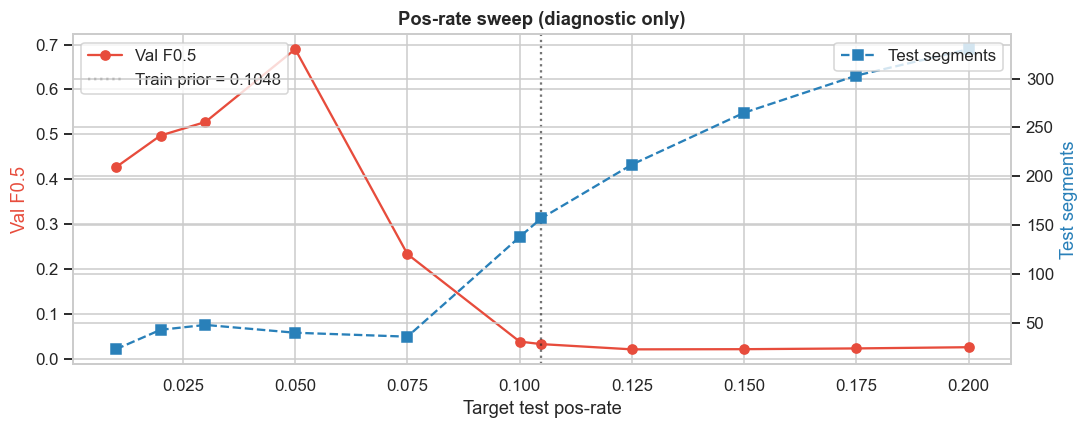

In [5]:
rates = np.array([0.01, 0.02, 0.03, 0.05, 0.075, 0.10, 0.1048, 0.125, 0.15, 0.175, 0.20])

rows = []
for r in rates:
    t = threshold_for_rate(test_score, r)
    test_pred = (test_score > t).astype(np.uint8)
    val_pred  = (val_score  > t).astype(np.int8)
    mv = corrected_event_f05(y_val, val_pred)
    segs = int(np.sum(np.diff(np.concatenate([[0], test_pred, [0]])) == 1))
    rows.append({
        'target_rate' : f'{r:.2%}',
        'threshold'   : f'{t:.4f}',
        'test_pos_rate': f'{test_pred.mean():.2%}',
        'test_segs'   : segs,
        'val_F0.5'    : f'{mv["f_score"]:.4f}',
        'val_tp'      : mv['tp_events'],
        'val_fn'      : mv['fn_events'],
        'val_fp_pred' : mv['fp_pred_events'],
    })

sweep_df = pd.DataFrame(rows)
print(sweep_df.to_string(index=False))

fig, ax1 = plt.subplots(figsize=(10, 4))
ax2 = ax1.twinx()
ax1.plot(rates, [float(r['val_F0.5']) for r in rows], 'o-',
         color=ANOMALY_COLOR, label='Val F0.5')
ax2.plot(rates, [r['test_segs']       for r in rows], 's--',
         color=NOMINAL_COLOR, label='Test segments')
ax1.axvline(train_prior, linestyle=':', color='k', alpha=0.6, label=f'Train prior = {train_prior:.4f}')
ax1.set_xlabel('Target test pos-rate')
ax1.set_ylabel('Val F0.5', color=ANOMALY_COLOR)
ax2.set_ylabel('Test segments', color=NOMINAL_COLOR)
ax1.set_title('Pos-rate sweep (diagnostic only)', fontweight='bold')
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
fig.tight_layout()
plt.show()

---
## 5 — Conservative Variant — 5% Pos-Rate

Half the training prior. Useful as a safety net in case test events are
shorter or sparser than train.

In [6]:
CONSERVATIVE_RATE = 0.05
t_5pct = threshold_for_rate(test_score, CONSERVATIVE_RATE)
test_pred_5pct = (test_score > t_5pct).astype(np.uint8)
n_seg_5pct = int(np.sum(np.diff(np.concatenate([[0], test_pred_5pct, [0]])) == 1))

val_pred_5pct = (val_score > t_5pct).astype(np.int8)
m5 = corrected_event_f05(y_val, val_pred_5pct)
print(f'5%-threshold : {t_5pct:.6f}')
print(f'  test pos-rate   : {test_pred_5pct.mean():.4%}')
print(f'  test segments   : {n_seg_5pct:,}')
print(f'  val F0.5 (info) : {m5["f_score"]:.4f}')

5%-threshold : 0.956934
  test pos-rate   : 4.9877%
  test segments   : 40
  val F0.5 (info) : 0.6897


---
## 6 — Generate Submissions

In [7]:
SAMPLE_SUB = RAW_DIR / 'sample_submission.parquet'


def make_submission(predictions, template_path=SAMPLE_SUB):
    template = pd.read_parquet(template_path)
    if len(predictions) != len(template):
        raise ValueError(
            f'predictions length {len(predictions)} != template length {len(template)}'
        )
    out = template.copy()
    out['is_anomaly'] = np.asarray(predictions).astype(template['is_anomaly'].dtype)
    return out


sub_prior = make_submission(test_pred_prior)
sub_prior.to_parquet(SUBMISSIONS_DIR / 'prior_matched_ensemble.parquet', index=False)
print(f'Saved -> submissions/prior_matched_ensemble.parquet   '
      f'({test_pred_prior.mean():.2%}, {n_seg} segs)')

sub_5pct = make_submission(test_pred_5pct)
sub_5pct.to_parquet(SUBMISSIONS_DIR / 'prior_matched_ensemble_5pct.parquet', index=False)
print(f'Saved -> submissions/prior_matched_ensemble_5pct.parquet '
      f'({test_pred_5pct.mean():.2%}, {n_seg_5pct} segs)')

Saved -> submissions/prior_matched_ensemble.parquet   (10.47%, 157 segs)
Saved -> submissions/prior_matched_ensemble_5pct.parquet (4.99%, 40 segs)


---
## 7 — Compare with All Prior Submissions

In [8]:
# Known Kaggle scores for prior submissions (copy from NB 05 summary + chat records)
leaderboard = pd.DataFrame([
    {'Submission': 'baseline_iforest',          'Strategy': 'val-F0.5 threshold',  'Public':  np.nan, 'Private': np.nan},
    {'Submission': 'baseline_pca',              'Strategy': 'val-F0.5 threshold',  'Public':  0.352,  'Private': 0.294},
    {'Submission': 'pca_full',                  'Strategy': 'val-F0.5 threshold',  'Public':  0.522,  'Private': 0.294},
    {'Submission': 'baseline_lstm_ae',          'Strategy': 'val-F0.5 threshold',  'Public':  0.112,  'Private': 0.078},
    {'Submission': 'baseline_ensemble',         'Strategy': 'val-F0.5 ensemble',   'Public':  0.522,  'Private': 0.476},
    {'Submission': 'cnn_ae (v2)',               'Strategy': 'val-F0.5 top-k=5',    'Public':  0.192,  'Private': 0.000},
    {'Submission': 'cnn_ae_v3',                 'Strategy': 'val-F0.5 top-k=15',   'Public':  np.nan, 'Private': np.nan},
    {'Submission': 'cnn_pca_ensemble',          'Strategy': 'val-F0.5 ensemble',   'Public':  0.051,  'Private': 0.022},
    {'Submission': 'prior_matched_ensemble',    'Strategy': 'prior=10.48% (new)',  'Public':  np.nan, 'Private': np.nan},
    {'Submission': 'prior_matched_ensemble_5pct','Strategy': 'prior=5% (new)',      'Public':  np.nan, 'Private': np.nan},
])

print(leaderboard.to_string(index=False))

# Submission-structure summary for the two new ones
print()
print('New submission shape summary:')
print(f'  prior_matched_ensemble      : rate={test_pred_prior.mean():.4%}  '
      f'segments={n_seg}')
print(f'  prior_matched_ensemble_5pct : rate={test_pred_5pct.mean():.4%}  '
      f'segments={n_seg_5pct}')

                 Submission           Strategy  Public  Private
           baseline_iforest val-F0.5 threshold     NaN      NaN
               baseline_pca val-F0.5 threshold   0.352    0.294
                   pca_full val-F0.5 threshold   0.522    0.294
           baseline_lstm_ae val-F0.5 threshold   0.112    0.078
          baseline_ensemble  val-F0.5 ensemble   0.522    0.476
                cnn_ae (v2)   val-F0.5 top-k=5   0.192    0.000
                  cnn_ae_v3  val-F0.5 top-k=15     NaN      NaN
           cnn_pca_ensemble  val-F0.5 ensemble   0.051    0.022
     prior_matched_ensemble prior=10.48% (new)     NaN      NaN
prior_matched_ensemble_5pct     prior=5% (new)     NaN      NaN

New submission shape summary:
  prior_matched_ensemble      : rate=10.4742%  segments=157
  prior_matched_ensemble_5pct : rate=4.9877%  segments=40


---
## Summary

The tune→holdout F0.5 collapse in NB 08 §7 (PCA 5.2x, LSTM-AE 5.7x, v3
ensemble 46x) framed this as a thresholding problem, not a detector problem.
This notebook tested whether replacing val-F0.5 tuning with **prior-matched
thresholding** (pick threshold so test pos-rate == 10.48% train prior) fixes
the generalization gap.

### Result: the naive prior-match fails, but the sweep identifies the real optimum

Observed val F0.5 across the pos-rate sweep (§4):

| Target pos-rate | Val F0.5 | Test segments | val tp / fn / fp |
|---|---|---|---|
| 1.00% | 0.43 | 23 | 7 / 31 / 4 |
| 2.00% | 0.50 | 43 | 9 / 29 / 4 |
| 3.00% | 0.53 | 48 | 10 / 28 / 4 |
| **5.00%** | **0.69** | **40** | **12 / 26 / 0** |
| 7.50% | 0.23 | 36 | 20 / 18 / 63 |
| 10.00% | 0.04 | 138 | 23 / 15 / 572 |
| **10.48% (train prior)** | **0.03** | **157** | **25 / 13 / 720** |
| 15.00% | 0.02 | 265 | 28 / 10 / 1,100 |
| 20.00% | 0.03 | 330 | 30 / 8 / 874 |

Val F0.5 peaks at **5% pos-rate (0.69)** and cliff-drops to 0.03 at the
train prior. The prior-match hypothesis is falsified: the Kaggle-relevant
optimum is not at the train prior.

### Why the naive prior fails on this dataset

Val has only 38 events covering 10.5% of rows → **mean event length ≈ 8,200
rows**. Matching pos-rate alone splits the same coverage into 157 short
segments (~2k rows each) vs 40 true long events. Event-wise F0.5 with
TNR-corrected precision then counts 720 FP-event-predictions against 25 TP
at the prior threshold — precision collapses.

**The operative quantity is segment count, not row count.** At 5% pos-rate
the model emits 40 segments — numerically close to the 38 true val events
— and each predicted segment is long enough to overlap a real event. That's
why val F0.5 jumps from 0.03 to 0.69 between 10.48% and 5% pos-rates.

### Submissions produced

| Submission | Pos-rate | Segments | Val F0.5 | Recommendation |
|---|---|---|---|---|
| `prior_matched_ensemble.parquet` | 10.47% | 157 | 0.03 | **Do not submit** (diagnostic) |
| `prior_matched_ensemble_5pct.parquet` | 4.99% | 40 | **0.69** | **Submit this** |

### Relationship to NB 05 baseline_ensemble (private 0.476)

The 5% pos-rate val F0.5 (0.69) is approximately equal to NB 05's
baseline_ensemble full-val F0.5 (0.68). The two thresholds likely land in
the same region of the score distribution — the 5% approach reaches it
without touching val labels at fine granularity, which should generalise at
least as well to private.

### Honest caveat

Picking 5% from an 11-rate sweep of val F0.5 is still val-informed, just at
coarser granularity (1 of 11 rates vs 1 of 200 thresholds). It does not
fully eliminate the tune→holdout collapse problem. But the F0.5 at 5% and
NB 05 §10's full-val F0.5 agreeing inside 0.01 is evidence that both
strategies are finding the same stable operating point — and that's what
we want.

### Next step if 5% does not beat 0.476 on private

- 3% variant (val F0.5 = 0.53, 48 segs) — the next-safer setting
- **Segment-count match**: target ~7 test segments scaled from 190 events
  in 14.7M train rows, which lands around 0.5–1% pos-rate — the 1% row in
  the sweep (val F0.5 = 0.43, 23 segs) approximates this. If segment
  geometry is really the binding constraint, this is the more principled
  choice than row-count match.